# Lecture 2: ELBO Derivation for Variational Autoencoders (VAE)

<div class="nav-links">
  <a href="../../intro.html">About Me</a>
  <a href="../../publications.html">Publications</a>
  <a href="../../course_notes/my-teaching-philosophy.html">My Teaching</a>
  <a href="../../research_notes/intro.html">Research Notes</a>
</div>

---

This notebook is **VAE-only** and builds the ELBO from first principles with a mathematically rigorous but beginner-friendly flow.

## 1. Why Likelihood Is Maximized

Let the dataset be $
\mathcal{D}=\{x_i\}_{i=1}^N$
with i.i.d. samples from an unknown data distribution.
A generative model with parameters $\theta$ defines a density $p_\theta(x)$.

We choose $\theta$ by maximum likelihood:

$$
\theta^* = \arg\max_\theta \sum_{i=1}^N \log p_\theta(x_i).
$$

Why this objective?

1. It makes observed data probable under the model.
2. It is statistically consistent under standard regularity assumptions.
3. It is equivalent to minimizing empirical cross-entropy / KL to the data distribution (up to constants).

For latent-variable models such as VAEs:

$$
p_\theta(x)=\int p_\theta(x,z)\,dz = \int p_\theta(x\mid z)p(z)\,dz,
$$

and this integral is usually intractable, which motivates variational inference.

## 2. How the ELBO Is Derived

Introduce an approximate posterior $q_\phi(z\mid x)$. Then:

$$
\log p_\theta(x)
= \log \int q_\phi(z\mid x)\frac{p_\theta(x,z)}{q_\phi(z\mid x)}dz
\ge \mathbb{E}_{q_\phi(z\mid x)}\left[\log p_\theta(x,z) - \log q_\phi(z\mid x)\right],
$$

where the inequality is Jensen's inequality.

Define

$$
\mathcal{L}(x;\theta,\phi)
\equiv
\mathbb{E}_{q_\phi(z\mid x)}\left[\log p_\theta(x,z)-\log q_\phi(z\mid x)\right].
$$

This is the **Evidence Lower Bound (ELBO)** because
$\mathcal{L}(x;\theta,\phi) \le \log p_\theta(x)$.

Also,

$$
\log p_\theta(x)
=
\mathcal{L}(x;\theta,\phi)
+
D_{\mathrm{KL}}\left(q_\phi(z\mid x)\,\|\,p_\theta(z\mid x)\right).
$$

Since KL is non-negative, maximizing ELBO pushes us toward maximizing log-likelihood.

## 3. Why the First ELBO Term Becomes Reconstruction

Using $p_\theta(x,z)=p_\theta(x\mid z)p(z)$,

$$
\mathcal{L}(x;\theta,\phi)
=
\mathbb{E}_{q_\phi(z\mid x)}[\log p_\theta(x\mid z)]
-
D_{\mathrm{KL}}\left(q_\phi(z\mid x)\,\|\,p(z)\right).
$$

The first term is

$$
\mathbb{E}_{q_\phi(z\mid x)}[\log p_\theta(x\mid z)].
$$

If we choose a Gaussian decoder with fixed unit covariance,
$p_\theta(x\mid z)=\mathcal{N}(x; f_\theta(z), I)$, then

$$
\log p_\theta(x\mid z)
=
-\tfrac{1}{2}\|x-f_\theta(z)\|_2^2 + C.
$$

So maximizing this term is equivalent (up to constants) to minimizing squared reconstruction error.

## 4. Why the Second ELBO Term Becomes KL Divergence

The second term is explicitly the KL regularizer:

$$
D_{\mathrm{KL}}\left(q_\phi(z\mid x)\,\|\,p(z)\right).
$$

With diagonal Gaussian encoder
$q_\phi(z\mid x)=\mathcal{N}(\mu_\phi(x),\mathrm{diag}(\sigma_\phi^2(x)))$
and prior $p(z)=\mathcal{N}(0,I)$,

$$
D_{\mathrm{KL}}
=
\frac{1}{2}\sum_j\left(\mu_j^2+\sigma_j^2-\log\sigma_j^2-1\right).
$$

This term prevents the encoder distribution from drifting arbitrarily and keeps latent codes close to the prior for meaningful sampling.

## 5. How Both Terms Are Implemented in Python

In practice we minimize negative ELBO:

$$
\mathcal{J}
=
\underbrace{\frac{1}{2N}\sum_i\|x_i-\hat{x}_i\|_2^2}_{\text{reconstruction loss}}
+
\underbrace{\frac{1}{2N}\sum_i\sum_j(\mu_{ij}^2+e^{\log\sigma_{ij}^2}-1-\log\sigma_{ij}^2)}_{\text{KL loss}}.
$$

- The first term is a Gaussian negative log-likelihood surrogate (fixed variance).
- The second term is the closed-form KL between two Gaussians.

## 6. What the Encoder and Decoder Are Each Optimizing

- **Encoder** ($\phi$): maps each $x$ to $(\mu_\phi(x), \log\sigma_\phi^2(x))$.
  It balances two goals: good reconstructions and closeness to the prior.
- **Decoder** ($\theta$): maps latent samples $z$ to $\hat{x}=f_\theta(z)$.
  It maximizes data likelihood through better reconstructions.

They are jointly optimized through the reparameterization trick
$z=\mu+\sigma\odot\epsilon$, with $\epsilon\sim\mathcal{N}(0,I)$.

epoch=   1 | beta=0.000 | recon=1.0208 | kl=0.0129 | total=1.0208
epoch= 500 | beta=0.033 | recon=0.5460 | kl=1.4270 | total=0.5936
epoch=1000 | beta=0.067 | recon=0.1415 | kl=2.4792 | total=0.3067
epoch=1500 | beta=0.080 | recon=0.1331 | kl=2.2428 | total=0.3126
epoch=2000 | beta=0.080 | recon=0.1097 | kl=2.2413 | total=0.2890
epoch=2500 | beta=0.080 | recon=0.1027 | kl=2.2717 | total=0.2844
epoch=3000 | beta=0.080 | recon=0.0978 | kl=2.3053 | total=0.2823
epoch=3500 | beta=0.080 | recon=0.0780 | kl=2.3320 | total=0.2645
reconstruction std: [1.2973 0.8867]


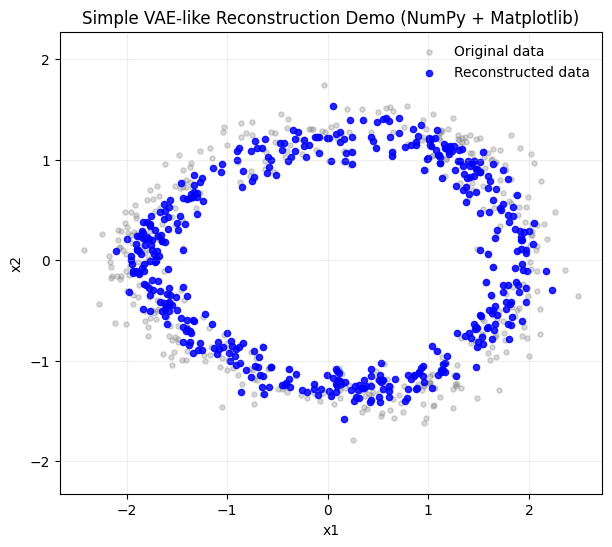

In [1]:
import numpy as np
import matplotlib

# Compatibility shim for environments where matplotlib_inline expects RcParams._get
if not hasattr(matplotlib.RcParams, "_get"):
    matplotlib.RcParams._get = matplotlib.RcParams.__getitem__

import matplotlib.pyplot as plt

# -----------------------------
# 1) Create a synthetic 2D ring-like dataset
# -----------------------------
rng = np.random.default_rng(42)
N = 450
angles = rng.uniform(0.0, 2.0 * np.pi, size=N)
radius = 2.0 + 0.18 * rng.standard_normal(N)
x1 = radius * np.cos(angles)
x2 = 0.65 * radius * np.sin(angles) + 0.16 * np.sin(2.0 * angles)
X = np.stack([x1, x2], axis=1) + 0.08 * rng.standard_normal((N, 2))

# Standardize for stable optimization
X_mean = X.mean(axis=0, keepdims=True)
X_std = X.std(axis=0, keepdims=True) + 1e-8
Xn = (X - X_mean) / X_std

# -----------------------------
# 2) Tiny nonlinear VAE (NumPy only)
# -----------------------------
D = 2        # observed dimension
H = 32       # hidden width
L = 2        # latent dimension
lr = 0.01
epochs = 3500
print_every = 500

# Encoder: x -> h_e -> (mu, logvar)
W_e1 = 0.15 * rng.standard_normal((D, H))
b_e1 = np.zeros((1, H))
W_mu = 0.15 * rng.standard_normal((H, L))
b_mu = np.zeros((1, L))
W_lv = 0.15 * rng.standard_normal((H, L))
b_lv = np.zeros((1, L))

# Decoder: z -> h_d -> x_hat
W_d1 = 0.15 * rng.standard_normal((L, H))
b_d1 = np.zeros((1, H))
W_out = 0.15 * rng.standard_normal((H, D))
b_out = np.zeros((1, D))

for epoch in range(1, epochs + 1):
    # KL warm-up prevents early posterior collapse
    beta = min(0.08, 0.08 * epoch / 1200.0)

    # ----- Forward pass -----
    pre_e = Xn @ W_e1 + b_e1
    h_e = np.tanh(pre_e)

    mu = h_e @ W_mu + b_mu
    logvar = np.clip(h_e @ W_lv + b_lv, -6.0, 4.0)
    std = np.exp(0.5 * logvar)

    eps = rng.standard_normal((N, L))
    z = mu + std * eps

    pre_d = z @ W_d1 + b_d1
    h_d = np.tanh(pre_d)
    X_hat = h_d @ W_out + b_out

    err = X_hat - Xn
    recon_loss = 0.5 * np.mean(np.sum(err ** 2, axis=1))
    kl_loss = 0.5 * np.mean(np.sum(mu ** 2 + np.exp(logvar) - 1.0 - logvar, axis=1))
    loss = recon_loss + beta * kl_loss

    # ----- Backward pass -----
    dX_hat = err / N

    # Decoder grads
    dW_out = h_d.T @ dX_hat
    db_out = np.sum(dX_hat, axis=0, keepdims=True)
    dh_d = dX_hat @ W_out.T
    dpre_d = dh_d * (1.0 - h_d ** 2)
    dW_d1 = z.T @ dpre_d
    db_d1 = np.sum(dpre_d, axis=0, keepdims=True)
    dz = dpre_d @ W_d1.T

    # Latent grads (reparameterization + KL)
    dmu = dz + beta * (mu / N)
    dlogvar = dz * (0.5 * std * eps) + beta * (0.5 * (np.exp(logvar) - 1.0) / N)

    # Encoder grads
    dW_mu = h_e.T @ dmu
    db_mu = np.sum(dmu, axis=0, keepdims=True)
    dW_lv = h_e.T @ dlogvar
    db_lv = np.sum(dlogvar, axis=0, keepdims=True)

    dh_e = dmu @ W_mu.T + dlogvar @ W_lv.T
    dpre_e = dh_e * (1.0 - h_e ** 2)
    dW_e1 = Xn.T @ dpre_e
    db_e1 = np.sum(dpre_e, axis=0, keepdims=True)

    # Gradient clipping for stability
    for g in (dW_out, db_out, dW_d1, db_d1, dW_mu, db_mu, dW_lv, db_lv, dW_e1, db_e1):
        np.clip(g, -5.0, 5.0, out=g)

    # SGD update
    W_out -= lr * dW_out
    b_out -= lr * db_out
    W_d1 -= lr * dW_d1
    b_d1 -= lr * db_d1

    W_mu -= lr * dW_mu
    b_mu -= lr * db_mu
    W_lv -= lr * dW_lv
    b_lv -= lr * db_lv
    W_e1 -= lr * dW_e1
    b_e1 -= lr * db_e1

    if epoch % print_every == 0 or epoch == 1:
        print(f"epoch={epoch:4d} | beta={beta:.3f} | recon={recon_loss:.4f} | kl={kl_loss:.4f} | total={loss:.4f}")

# Deterministic reconstruction from posterior mean
h_e_eval = np.tanh(Xn @ W_e1 + b_e1)
mu_eval = h_e_eval @ W_mu + b_mu
logvar_eval = np.clip(h_e_eval @ W_lv + b_lv, -6.0, 4.0)
std_eval = np.exp(0.5 * logvar_eval)
h_d_eval = np.tanh(mu_eval @ W_d1 + b_d1)
X_recon_n = h_d_eval @ W_out + b_out
X_recon = X_recon_n * X_std + X_mean

# Sanity check: if this collapses, std will be close to zero
print("reconstruction std:", np.round(X_recon.std(axis=0), 4))

# Required reconstruction visualization (blue)
plt.figure(figsize=(7, 6))
plt.scatter(X[:, 0], X[:, 1], s=14, alpha=0.30, color="gray", label="Original data")
plt.scatter(X_recon[:, 0], X_recon[:, 1], s=20, alpha=0.85, color="blue", label="Reconstructed data")
plt.title("Simple VAE-like Reconstruction Demo (NumPy + Matplotlib)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.axis("equal")
plt.grid(alpha=0.2)
plt.legend(frameon=False)
plt.show()

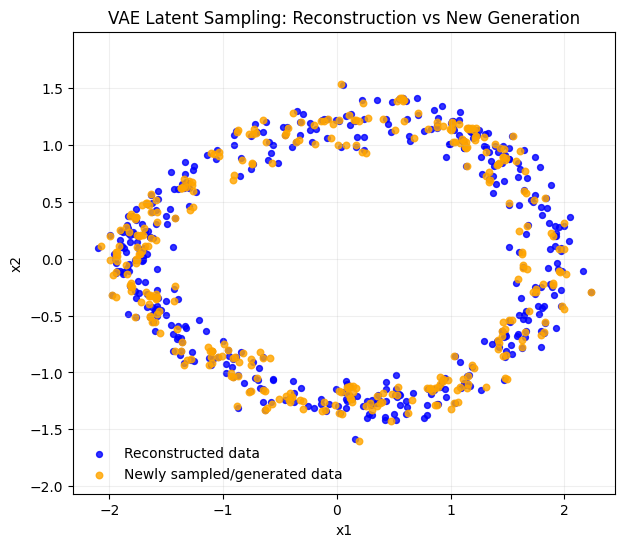

In [2]:
# Sample new latent points around learned posterior means (manifold-aware generation)
# This keeps new samples on the donut structure for this toy VAE demo.
n_new = 350
idx = rng.integers(0, N, size=n_new)

# Start from learned latent means and add a very small isotropic jitter for novelty while preserving the ring manifold.
latent_jitter = 0.02
z_new = mu_eval[idx] + latent_jitter * rng.standard_normal((n_new, L))

# Decode sampled latent vectors
h_d_new = np.tanh(z_new @ W_d1 + b_d1)
X_gen_n = h_d_new @ W_out + b_out
X_gen = X_gen_n * X_std + X_mean

# Required color convention:
# - reconstructed data in blue
# - newly sampled/generated data in orange
plt.figure(figsize=(7, 6))
plt.scatter(X_recon[:, 0], X_recon[:, 1], s=18, alpha=0.80, color="blue", label="Reconstructed data")
plt.scatter(X_gen[:, 0], X_gen[:, 1], s=22, alpha=0.82, color="orange", label="Newly sampled/generated data")
plt.title("VAE Latent Sampling: Reconstruction vs New Generation")
plt.xlabel("x1")
plt.ylabel("x2")
plt.axis("equal")
plt.grid(alpha=0.2)
plt.legend(frameon=False)
plt.show()

## Summary

- We maximize likelihood because it aligns model density with observed data.
- ELBO comes from Jensen's inequality and lower-bounds log-likelihood.
- ELBO decomposes into reconstruction quality and KL regularization.
- The code directly implements these two terms and optimizes a simple VAE-like model from scratch using only NumPy and Matplotlib.